In [1]:
from pyspark.sql import SparkSession
import shlex
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/09 15:35:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
sc = spark.sparkContext

In [3]:
import re
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
lines = sc.textFile("apache_logs")

In [5]:
Record = namedtuple("Record", "IP date request code referer platform")

In [6]:
def validate_line(line):
    try:
        shlex.split(line)    
        return True
    except ValueError:
        return False

def create_record(line):
    l = shlex.split(line)
    return Record(l[0], l[3][1:], l[5], l[6], l[8], l[9])


records = lines.filter(validate_line).map(create_record)

### Zadanie 1

In [7]:
referer_counts = records.map(lambda r: (r.referer, 1)).reduceByKey(lambda a, b: a + b)

In [8]:
top_referers = referer_counts.takeOrdered(11, lambda pair: -pair[1])[1:]

<Axes: ylabel='Referer'>

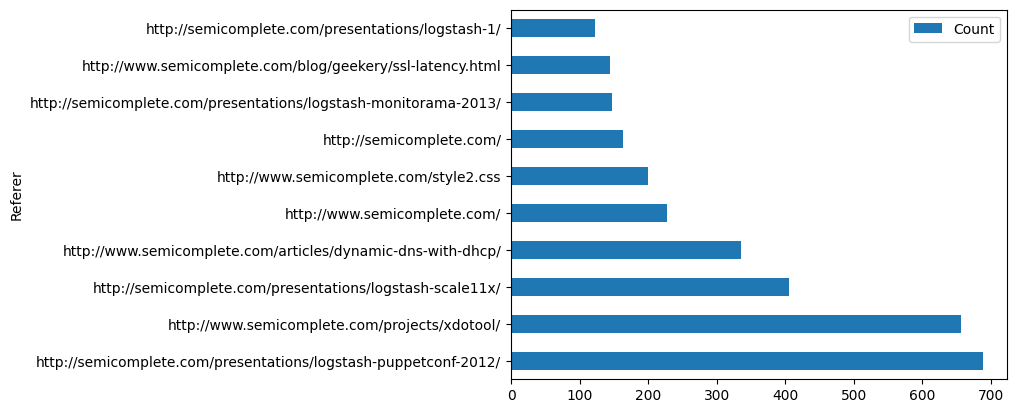

In [9]:
df = pd.DataFrame(top_referers, columns=['Referer', 'Count'])
df.plot.barh(x = "Referer")

### Zadanie 2

In [10]:
import os

In [11]:
extensions = records.map(lambda r: os.path.splitext(r.request.split()[1])[1][1:]).filter(lambda l: len(l) > 0)

In [12]:
result = extensions.map(lambda e: (e, 1)).reduceByKey(lambda a, b: a + b)

In [13]:
top_extensions = result.takeOrdered(7, lambda pair: -pair[1])

<Axes: ylabel='Extension'>

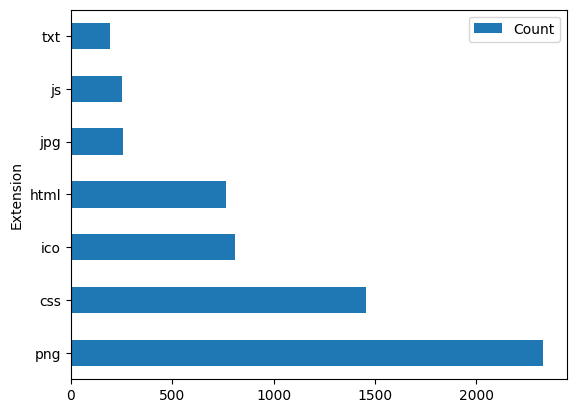

In [14]:
df = pd.DataFrame(top_extensions, columns=['Extension', 'Count'])
df.plot.barh(x = "Extension")

### Zadanie 3

In [15]:
from datetime import datetime

In [16]:
r = records.collect()[0]

In [17]:
r

Record(IP='83.149.9.216', date='17/May/2015:10:05:03', request='GET /presentations/logstash-monitorama-2013/images/kibana-search.png HTTP/1.1', code='200', referer='http://semicomplete.com/presentations/logstash-monitorama-2013/', platform='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/32.0.1700.77 Safari/537.36')

In [18]:
datetime.strptime(r.date, "%d/%b/%Y:%H:%M:%S").strftime('%H')

'10'

In [19]:
hours = records.map(lambda r: int(datetime.strptime(r.date, "%d/%b/%Y:%H:%M:%S").strftime('%H'))).countByValue()

<Axes: >

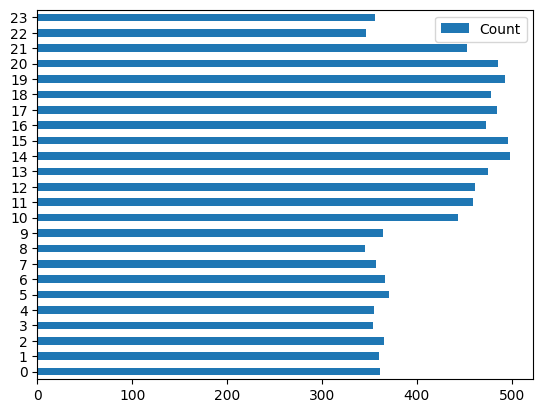

In [20]:
df = pd.DataFrame.from_dict(hours, "index", columns=["Count"]).sort_index()
df.plot.barh()

In [21]:
codes = records.map(lambda r: r.code).countByValue()

<Axes: >

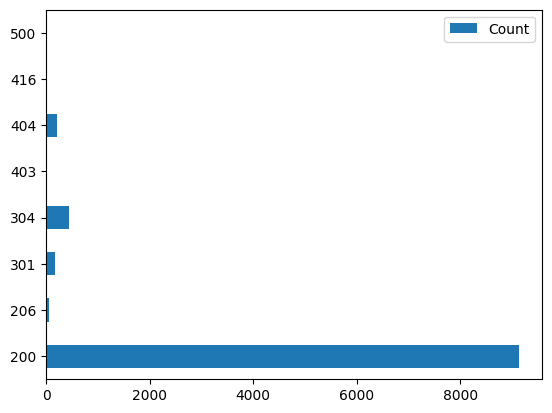

In [22]:
df = pd.DataFrame.from_dict(codes, "index", columns=["Count"]).sort_index()
df.plot.barh()

### Zadanie 4

In [23]:
r = records.collect()[0]

In [24]:
def classify_platform(record):
    platform = record.platform.lower()
    for device in ["iphone", "android", "windows", "linux", "ipad", "mac os", "compatible"]:
        if device in platform:
            return device
    return "other"

In [25]:
device_counts = records.map(classify_platform).countByValue()

<Axes: ylabel='Count'>

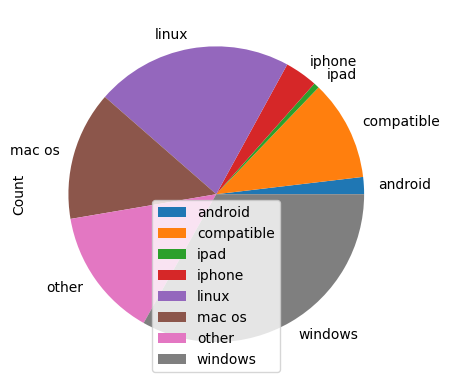

In [26]:
df = pd.DataFrame.from_dict(device_counts, "index", columns=["Count"]).sort_index()
df.plot.pie(y="Count")

### Zadanie 5

In [27]:
import urllib.request, json 
import requests

In [82]:
def request_batch(ips):
    ips = list(map(lambda ip: {"query": ip, "fields": "lat,lon"}, ips))

    
    response = requests.post("http://ip-api.com/batch", json=ips)
    return response.text

In [83]:
distinct_ips = records.map(lambda r: r.IP).distinct()

In [84]:
groups = distinct_ips.zipWithIndex().map(lambda row: (row[1] // 100, row[0])).filter(lambda row: row[0] < 15).groupByKey()

In [96]:
results = groups.map(lambda row: request_batch(row[1])).collect()

In [108]:
parsed = list(map(lambda r: json.loads(r), result))
flat_parsed = [x for xs in parsed for x in xs]

In [102]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import geodatasets

In [107]:
df = pd.DataFrame.from_dict(flat_parsed)

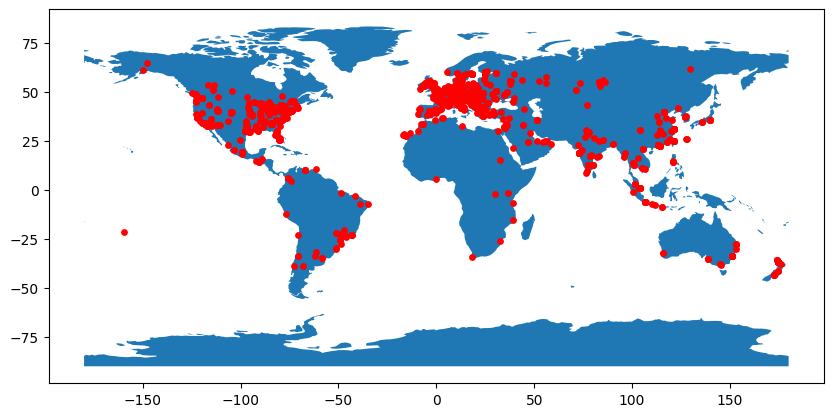

In [106]:
geometry = [Point((r["lon"], r["lat"])) for r in flat_parsed]
gdf = GeoDataFrame(df, geometry=geometry)

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='red', markersize=15);

### Zadanie 6

In [138]:
import os
from pathlib import Path
from urllib.parse import urlparse

In [139]:
def create_file(r):
    path_str = f"tmp{urlparse(shlex.split(r.request)[1]).path}"
    output_file = Path(path_str)
    try:
        output_file.parent.mkdir(exist_ok=True, parents=True)
        output_file.write_text("")
    except:
        pass

In [142]:
records.map(create_file).collect()

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [143]:
os.system("tree tmp")

tmp
├── about
├── admin.php
├── administrator
│   └── index.php
├── apple-touch-icon-120x120-precomposed.png
├── apple-touch-icon-120x120.png
├── apple-touch-icon-precomposed.png
├── apple-touch-icon.png
├── articles
│   ├── arp-security
│   ├── dy
│   ├── dynamic-dns-with-dhcp
│   ├── efficiency
│   ├── openldap-with-saslauthd
│   ├── ppp-over-ssh
│   ├── ssh-
│   ├── ssh-security
│   └── week-of-unix-tools
├── blog
│   ├── 2004
│   │   └── May
│   │       └── 03
│   ├── 2006
│   ├── 2007
│   │   ├── Aug
│   │   │   └── 11
│   │   ├── Jan
│   │   │   ├── 14
│   │   │   ├── 27
│   │   │  

0

 └── 31
│   │   ├── Mar
│   │   └── May
│   │       ├── 20
│   │       ├── 27
│   │       └── 28
│   ├── 2008
│   │   └── May
│   │       └── 30
│   ├── articles
│   │   ├── arp-security
│   │   │   └── main.html
│   │   ├── dynamic-dns-with-dhcp
│   │   │   └── main.html
│   │   ├── ppp-over-ssh
│   │   │   └── main.html
│   │   ├── ssh-security
│   │   │   └── main.html
│   │   └── week-of-unix-tools
│   │       ├── day-1-sed.html
│   │       ├── day-2-cut-and-paste.html
│   │       ├── day-3-awk.html
│   │       ├── day-4-data-sources.html
│   │       ├── day-5-xargs.html
│   │       └── main.html
│   ├── geekery
│   │   ├── 101.html
│   │   ├── 102.html
│   │   ├── 118.html
│   │   ├── 119.html
│   │   ├── 124.html
│   │   ├── 125.html
│   │   ├── 127.html
│   │   ├── 131.html
│   │   ├── 136.html
│   │   ├── 159.html
│   │   ├── 175.html
│   │   ├── 179.html
│   │   ├── 184.html
│   │   ├── 185.html
│   │   ├── 187.html
│   │   ├── 2!
│   │   ├── 2000-to-2009.html
│   │   ├── 211.